# Day 4 — Attention & Transformers

## Google Play Store Review Sentiment Classification

**Dataset:** Google Play Store Apps — Kaggle  
**NLP task:** Sentiment Classification  
**Models:** LSTM vs. DistilBERT Transformer  
**Tools:** TensorFlow/Keras, Hugging Face Transformers, scikit-learn, Jupyter/Colab

---

### Learning Objectives

By the end of this notebook, we will be able to:

- Explain the limitation of step-by-step RNNs that Transformers overcome.
- Explain self-attention and why it can access all positions directly.
- Explain why Transformer training is highly parallelizable.
- Explain long-range context conceptually.
- Explain the role of positional information in Transformers.
- Distinguish encoder-style models such as BERT/DistilBERT from decoder-style models such as GPT-2.
- Load and use a pre-trained Transformer from Hugging Face.
- Apply a Transformer to real Google Play user reviews.
- Build a text LSTM baseline on the same reviews for a fair model comparison.
- Evaluate both models using Accuracy, Precision, Recall, F1-score and a confusion matrix.
- Select the project's core architecture based on the experiment.

##  Why Do We Need Transformers?

In Day 3, we learned that an RNN/LSTM processes a sequence recurrently:

```text
token 1 → token 2 → token 3 → token 4 → ...
   ↓        ↓        ↓        ↓
 memory → memory → memory → memory
```

The next step depends on the previous hidden state.

This gives recurrent models a form of memory, but it also creates an important limitation:

> The sequence is processed step by step, which limits parallelism during training.

LSTMs improve the learning of long-term dependencies compared with a plain RNN, but they still retain the recurrent step-by-step structure.

Transformers remove recurrence and use **attention** to allow positions in a sequence to interact directly.

##  The Attention Mechanism

The key idea is **self-attention**.

Instead of asking:

> "What information was carried through all previous recurrent steps?"

the Transformer can ask:

> "Which other tokens in this sequence are relevant to this token?"

Conceptually:

```text
"This app is slow but its interface is excellent"

                         attention
                            ↕
             ┌──────────────┼──────────────┐
             ↓              ↓              ↓
           "app"          "slow"      "excellent"
```

Each position can assign different importance to other positions.

### Why is this powerful?

| Idea | What it does |
|---|---|
| Self-attention | Each token weighs the relevance of other tokens |
| Parallelism | Positions can be processed together rather than recurrently |
| Long-range context | Distant tokens can interact directly |
| Contextual representation | A token's representation depends on surrounding context |

For example, in:

> "The app is slow, but its design is beautiful."

the representation of **"its"** can use information from **"app"** directly through attention.

##  Transformer Architecture

A Transformer is built from repeated blocks containing attention and feed-forward components.

A simplified view is:

```text
Input Tokens
     ↓
Token Embeddings
     +
Positional Information
     ↓
Self-Attention
     ↓
Feed-Forward Network
     ↓
More Transformer Blocks
     ↓
Task-specific Output
```

### Positional Information

Unlike an RNN, a Transformer does not automatically process tokens one after another.

Therefore, the model needs information about token position.

Conceptually:

```text
Token embedding + position information
                ↓
       Transformer input
```

Position tells the model that:

```text
"not good"
```

is different from:

```text
"good not"
```

Modern Transformer implementations can use different positional-information mechanisms. For this program, the important concept is that **order must be represented explicitly or through a positional mechanism**.

##  Pre-trained Transformers

Transformers can be pre-trained on very large text corpora and then reused for downstream tasks.

This is similar to the transfer-learning idea from computer vision.

### Common examples

- **BERT** — encoder-style Transformer, commonly used for language understanding and classification.
- **DistilBERT** — a smaller, faster distilled version of BERT that is useful when computational resources are limited.
- **GPT-2** — decoder-style Transformer designed primarily for autoregressive text generation.

For today's sentiment-classification task, we will use **DistilBERT** because it is practical for Colab and designed from BERT's encoder family for language understanding.

#  Setup — Google Colab

We will download the Kaggle dataset using kagglehub.

## Import Libraries

In [1]:
!pip uninstall -y transformers
!pip install -q "transformers==4.46.3"

Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3


In [2]:
import transformers
print(transformers.__version__)

4.46.3


In [3]:
from transformers import TFAutoModelForSequenceClassification

print("OK")

OK


In [4]:
import os
import re
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    pipeline,
    AutoTokenizer,
    TFAutoModelForSequenceClassification
)

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("Transformers:", __import__("transformers").__version__)

TensorFlow: 2.20.0
Transformers: 4.46.3


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [6]:
transformer_model = TFAutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

print("Transformer model loaded successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Transformer model loaded successfully.


#  Download the Google Play Store Dataset

Kaggle dataset:

`lava18/google-play-store-apps`

The dataset contains information about Google Play applications and a separate user-review file.

For today's NLP task, we will use:

**`googleplaystore_user_reviews.csv`**

The important columns are expected to include:

- `App`
- `Translated_Review`
- `Sentiment`
- `Sentiment_Polarity`
- `Sentiment_Subjectivity`

Our target will be **Sentiment**.

In [7]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "lava18/google-play-store-apps"
)

print("Dataset path:")
print(dataset_path)

print("\nFiles found:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 1.94M/1.94M [00:00<00:00, 100MB/s]

Extracting files...
Dataset path:
/root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6

Files found:
/root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6/license.txt
/root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6/googleplaystore_user_reviews.csv
/root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6/googleplaystore.csv


In [8]:
reviews_path = None

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower() == "googleplaystore_user_reviews.csv":
            reviews_path = os.path.join(root, file)

print("Reviews file:", reviews_path)

if reviews_path is None:
    raise FileNotFoundError(
        "googleplaystore_user_reviews.csv was not found."
    )

Reviews file: /root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6/googleplaystore_user_reviews.csv


#  Load and Inspect the Reviews

Each row represents a user review.

For the NLP experiment:

```text
Translated_Review → input text
Sentiment         → target label
```

In [9]:
reviews_df = pd.read_csv(reviews_path)

print("Shape:", reviews_df.shape)
display(reviews_df.head())

print("\nColumns:")
print(reviews_df.columns.tolist())

print("\nData types:")
print(reviews_df.dtypes)

Shape: (64295, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000



Columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

Data types:
App                        object
Translated_Review          object
Sentiment                  object
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
dtype: object


In [10]:
print("Missing values:")
display(reviews_df.isnull().sum())

print("\nDuplicate rows:", reviews_df.duplicated().sum())

Missing values:


,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863



Duplicate rows: 33616


#  Clean the Text Dataset

The review file may contain:

- missing review text
- missing sentiment
- duplicated rows
- neutral reviews

We will keep only rows with valid text and one of the three sentiment labels.

The original sentiment labels are:

```text
Positive
Negative
Neutral
```

This makes the task a **3-class classification problem**.

In [11]:
df = reviews_df[
    ["App", "Translated_Review", "Sentiment"]
].copy()

df = df.dropna(subset=["Translated_Review", "Sentiment"])

df["Translated_Review"] = (
    df["Translated_Review"]
    .astype(str)
    .str.strip()
)

df["Sentiment"] = (
    df["Sentiment"]
    .astype(str)
    .str.strip()
)

df = df[df["Translated_Review"].str.len() > 0]

df = df[
    df["Sentiment"].isin(
        ["Positive", "Negative", "Neutral"]
    )
]

df = df.drop_duplicates(
    subset=["Translated_Review", "Sentiment"]
).reset_index(drop=True)

print("Clean shape:", df.shape)
display(df.head())

Clean shape: (27994, 3)


,App,Translated_Review,Sentiment
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive
2,10 Best Foods for You,Works great especially going grocery store,Positive
3,10 Best Foods for You,Best idea us,Positive
4,10 Best Foods for You,Best way,Positive


In [12]:
print("Class distribution:")
class_counts = df["Sentiment"].value_counts()
display(class_counts.to_frame("Count"))

Class distribution:


,Count
Sentiment,
Positive,17593
Negative,6240
Neutral,4161


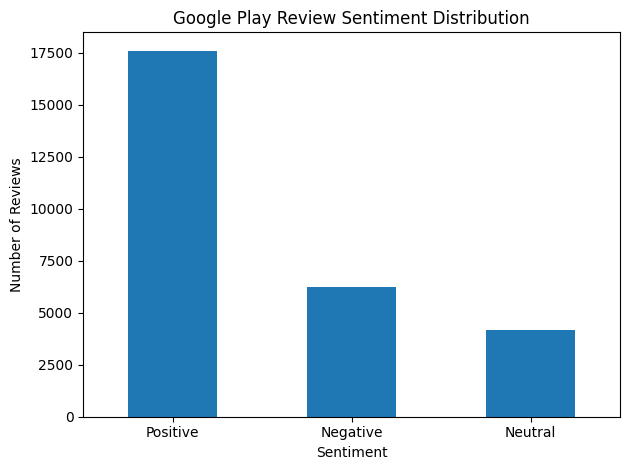

In [13]:
class_counts.plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Google Play Review Sentiment Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Convert Labels to Numbers

Neural networks work with numerical labels.

We will use:

```text
Negative → 0
Neutral  → 1
Positive → 2
```

In [14]:
LABEL_MAP = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

ID_TO_LABEL = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

df["label"] = df["Sentiment"].map(LABEL_MAP)

print(df["label"].value_counts().sort_index())

label
0     6240
1     4161
2    17593
Name: count, dtype: int64


#  Train / Validation / Test Split

We use:

- **Training set** — learns model parameters.
- **Validation set** — monitors performance during training/model selection.
- **Test set** — final unbiased evaluation.

We use stratification so that the class proportions remain approximately consistent.

In [15]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (22395, 4)
Validation: (2799, 4)
Test: (2800, 4)


In [16]:
print("Train distribution:")
display(train_df["Sentiment"].value_counts())

print("\nValidation distribution:")
display(val_df["Sentiment"].value_counts())

print("\nTest distribution:")
display(test_df["Sentiment"].value_counts())

Train distribution:


,count
Sentiment,
Positive,14074
Negative,4992
Neutral,3329



Validation distribution:


,count
Sentiment,
Positive,1759
Negative,624
Neutral,416



Test distribution:


,count
Sentiment,
Positive,1760
Negative,624
Neutral,416


#  Step 1 — Pre-trained Transformer with Hugging Face Pipeline

First, we satisfy the basic inference requirement using Hugging Face `pipeline`.

The pipeline automatically:

1. loads a tokenizer,
2. loads a pre-trained model,
3. tokenizes the input,
4. runs inference,
5. returns a prediction and confidence score.

We will start with a sample sentence.

In [17]:
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

sample_text = "This app is excellent and very easy to use!"

result = classifier(sample_text)

print(result)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


[{'label': 'POSITIVE', 'score': 0.9998237490653992}]


###  interpretation

The model above is pre-trained for **binary English sentiment**:

```text
POSITIVE
NEGATIVE
```

Our Google Play dataset contains **three classes**:

```text
Positive
Neutral
Negative
```

Therefore, we should not pretend that the binary pipeline directly solves the complete 3-class task.

For a fair 3-class experiment, we will use the pre-trained DistilBERT model as a starting point and fine-tune it on the Google Play reviews.

This demonstrates the difference between:

- **Inference with an existing pipeline**
- **Fine-tuning a pre-trained Transformer for our own task**

#  Inspect the Transformer

The model we use is:

**DistilBERT**

It is a smaller Transformer derived from BERT through knowledge distillation.

Conceptually:

```text
Google Play Review
       ↓
   Tokenizer
       ↓
   DistilBERT
       ↓
Contextual representation
       ↓
Classification head
       ↓
Negative / Neutral / Positive
```

In [18]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

transformer_model = TFAutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

transformer_model.summary()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Model: "tf_distil_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  2307      
                                                                 
 dropout_39 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66955779 (255.42 MB)
Trainable params: 66955779 (255.42 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#  Create a Practical Training Subset

Full Transformer fine-tuning can take significant time in Colab.

To keep the 8-hour lab practical, we define a configurable subset.

If you have a GPU and enough time, increase `MAX_TRAIN` and `MAX_EVAL`.

If your runtime is slow, keep the default values.

**Important:** the final metric reported by this notebook belongs to the subset used in your actual run. Do not copy a metric from another run.

In [19]:
MAX_TRAIN = 6000
MAX_VAL = 1000
MAX_TEST = 1000

train_small = train_df.sample(
    n=min(MAX_TRAIN, len(train_df)),
    random_state=SEED
)

val_small = val_df.sample(
    n=min(MAX_VAL, len(val_df)),
    random_state=SEED
)

test_small = test_df.sample(
    n=min(MAX_TEST, len(test_df)),
    random_state=SEED
)

print("Transformer train:", train_small.shape)
print("Transformer validation:", val_small.shape)
print("Transformer test:", test_small.shape)

Transformer train: (6000, 4)
Transformer validation: (1000, 4)
Transformer test: (1000, 4)


#  Tokenization
Transformers do not receive raw strings directly.
The tokenizer converts text into token IDs.
For example:

```text
"This app is excellent"
        ↓
tokens
        ↓
[CLS] this app is excellent [SEP]
        ↓
token IDs
```
The tokenizer also creates attention masks.
An attention mask tells the model which positions are real tokens and which positions are padding.

In [20]:
MAX_LENGTH = 128

def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="tf"
    )

train_tokens = tokenize_texts(train_small["Translated_Review"])
val_tokens = tokenize_texts(val_small["Translated_Review"])
test_tokens = tokenize_texts(test_small["Translated_Review"])

print("Input IDs shape:", train_tokens["input_ids"].shape)
print("Attention mask shape:", train_tokens["attention_mask"].shape)

Input IDs shape: (6000, 128)
Attention mask shape: (6000, 128)


# Prepare TensorFlow Datasets

We pair:

```text
tokenized review → label
```

and create efficient batches for training.

In [21]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "input_ids": train_tokens["input_ids"],
            "attention_mask": train_tokens["attention_mask"]
        },
        train_small["label"].values
    )
).shuffle(
    len(train_small),
    seed=SEED
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "input_ids": val_tokens["input_ids"],
            "attention_mask": val_tokens["attention_mask"]
        },
        val_small["label"].values
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "input_ids": test_tokens["input_ids"],
            "attention_mask": test_tokens["attention_mask"]
        },
        test_small["label"].values
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets prepared.")

Datasets prepared.


#  Fine-tune the Pre-trained Transformer

This is the transfer-learning idea applied to NLP:

```text
Pre-trained DistilBERT
        ↓
Keep learned language representations
        ↓
Adapt/fine-tune on Google Play reviews
        ↓
3-class sentiment classifier
```

We use a small learning rate because the Transformer already contains useful pre-trained representations.

In [22]:
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=2e-5
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

print("Transformer compiled successfully.")

Transformer compiled successfully.


In [23]:
from tf_keras.callbacks import EarlyStopping

transformer_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

transformer_history = transformer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3,
    callbacks=[transformer_early_stopping],
    verbose=1
)

transformer_training_time = time.time() - start_time

print(
    f"Transformer training time: "
    f"{transformer_training_time:.2f} seconds"
)

Epoch 1/3
375/375 [==============================] - 118s 246ms/step - loss: 0.5297 - accuracy: 0.7828 - val_loss: 0.3217 - val_accuracy: 0.8870
Epoch 2/3
375/375 [==============================] - 87s 231ms/step - loss: 0.2605 - accuracy: 0.9108 - val_loss: 0.2802 - val_accuracy: 0.9000
Epoch 3/3
375/375 [==============================] - 86s 230ms/step - loss: 0.1634 - accuracy: 0.9518 - val_loss: 0.2962 - val_accuracy: 0.8950
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Transformer training time: 346.41 seconds


# Transformer Learning Curves

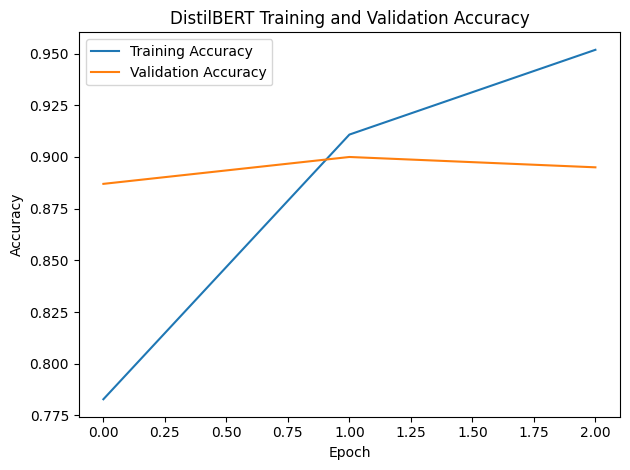

In [24]:
plt.plot(
    transformer_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    transformer_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DistilBERT Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

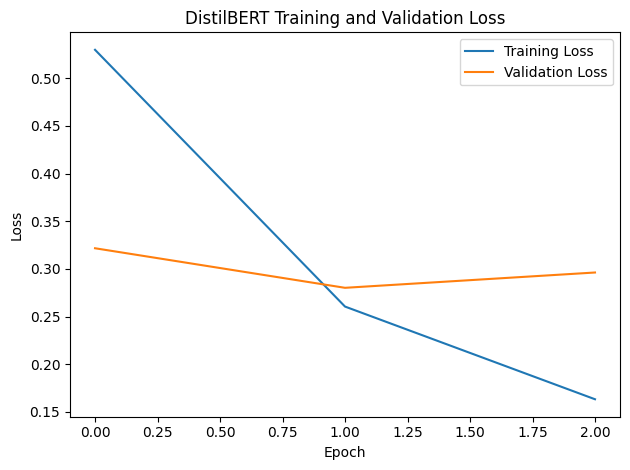

In [25]:
plt.plot(
    transformer_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    transformer_history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

#  Transformer Evaluation

We evaluate the fine-tuned model on the untouched test subset.

We will calculate:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Classification report
- Confusion matrix

In [26]:
start_time = time.time()

transformer_logits = transformer_model.predict(
    test_dataset,
    verbose=1
).logits

transformer_predictions = np.argmax(
    transformer_logits,
    axis=1
)

transformer_prediction_time = time.time() - start_time

y_test_transformer = test_small["label"].values

transformer_accuracy = accuracy_score(
    y_test_transformer,
    transformer_predictions
)

transformer_precision = precision_score(
    y_test_transformer,
    transformer_predictions,
    average="weighted",
    zero_division=0
)

transformer_recall = recall_score(
    y_test_transformer,
    transformer_predictions,
    average="weighted",
    zero_division=0
)

transformer_f1 = f1_score(
    y_test_transformer,
    transformer_predictions,
    average="weighted",
    zero_division=0
)

print("DistilBERT Results")
print("=" * 45)
print(f"Accuracy : {transformer_accuracy:.4f}")
print(f"Precision: {transformer_precision:.4f}")
print(f"Recall   : {transformer_recall:.4f}")
print(f"F1 Score : {transformer_f1:.4f}")
print(f"Prediction Time: {transformer_prediction_time:.2f}s")

63/63 [==============================] - 6s 76ms/step
DistilBERT Results
Accuracy : 0.8960
Precision: 0.8953
Recall   : 0.8960
F1 Score : 0.8940
Prediction Time: 6.53s


In [27]:
print("DistilBERT Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test_transformer,
        transformer_predictions,
        target_names=[
            ID_TO_LABEL[i] for i in range(3)
        ],
        digits=4,
        zero_division=0
    )
)

DistilBERT Classification Report
              precision    recall  f1-score   support

    Negative     0.8598    0.7931    0.8251       232
     Neutral     0.9115    0.7687    0.8340       134
    Positive     0.9049    0.9606    0.9319       634

    accuracy                         0.8960      1000
   macro avg     0.8921    0.8408    0.8637      1000
weighted avg     0.8953    0.8960    0.8940      1000



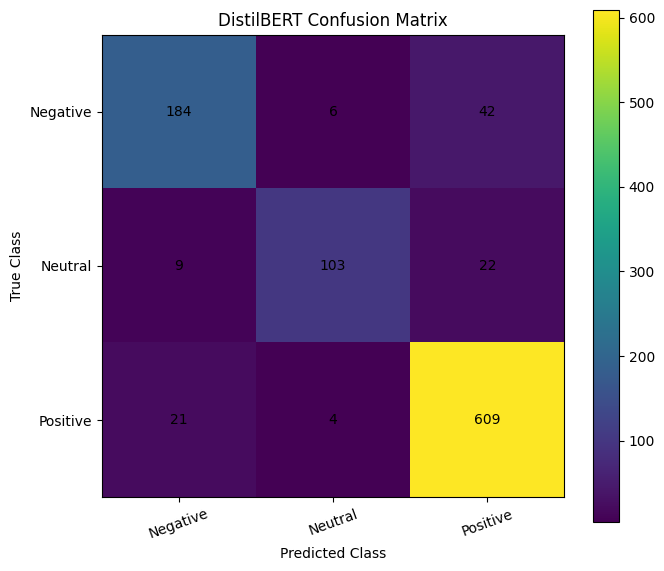

In [28]:
cm_transformer = confusion_matrix(
    y_test_transformer,
    transformer_predictions
)

plt.figure(figsize=(7, 6))
plt.imshow(cm_transformer)
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(3),
    [ID_TO_LABEL[i] for i in range(3)],
    rotation=20
)

plt.yticks(
    range(3),
    [ID_TO_LABEL[i] for i in range(3)]
)

plt.colorbar()

for i in range(cm_transformer.shape[0]):
    for j in range(cm_transformer.shape[1]):
        plt.text(
            j,
            i,
            cm_transformer[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# Step 2 — Fair LSTM Baseline on the Same Google Play Reviews

The official Day 3 notebook used an **ECG heartbeat dataset** and a tuned LSTM for sequence classification. Its final test accuracy was 92.29% and weighted F1-score was 92.57%. However, that result is **not directly comparable** with Google Play sentiment classification because the input modality, task, labels, and dataset are completely different.

For today's comparison, we therefore train a **new text LSTM on the same Google Play reviews**.

This gives us an apples-to-apples comparison:

```text
Same reviews
Same labels
Same train/validation/test split
        ↓
   ┌───────────┐
   │   LSTM    │
   └───────────┘

        vs.

   ┌───────────────┐
   │  DistilBERT   │
   │  Transformer  │
   └───────────────┘
```


#  Text Preprocessing for LSTM

The LSTM needs numerical sequences.

Pipeline:

```text
Review text
   ↓
Keras TextVectorization
   ↓
Integer token sequence
   ↓
Embedding
   ↓
LSTM
   ↓
Dense
   ↓
3 sentiment classes
```

In [29]:
MAX_TOKENS = 15000
LSTM_SEQUENCE_LENGTH = 100

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=LSTM_SEQUENCE_LENGTH
)

vectorizer.adapt(
    train_small["Translated_Review"].values
)

print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Vocabulary size: 10862


In [30]:
X_train_text = vectorizer(
    tf.constant(train_small["Translated_Review"].values)
)

X_val_text = vectorizer(
    tf.constant(val_small["Translated_Review"].values)
)

X_test_text = vectorizer(
    tf.constant(test_small["Translated_Review"].values)
)

y_train_text = train_small["label"].values
y_val_text = val_small["label"].values
y_test_text = test_small["label"].values

print("X_train:", X_train_text.shape)
print("X_val:", X_val_text.shape)
print("X_test:", X_test_text.shape)

X_train: (6000, 100)
X_val: (1000, 100)
X_test: (1000, 100)


#  Build the Text LSTM

Unlike the ECG LSTM from Day 3, this LSTM receives **word-token sequences**.

The architecture is intentionally small so that the experiment is practical in Colab.

In [31]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential([
    Embedding(
        input_dim=MAX_TOKENS,
        output_dim=64
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        3,
        activation="softmax"
    )
])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("LSTM compiled successfully.")

LSTM compiled successfully.


In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_text)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_text
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.4847809948032664), np.int64(1): np.float64(2.2346368715083798), np.int64(2): np.float64(0.532197977647685)}


In [45]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_text,
    y_train_text,
    validation_data=(
        X_val_text,
        y_val_text
    ),
    epochs=5,
    batch_size=64,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )
    ]
)

lstm_training_time = time.time() - start_time

print(
    f"LSTM training time: "
    f"{lstm_training_time:.2f} seconds"
)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3763 - loss: 1.1088 - val_accuracy: 0.1480 - val_loss: 1.1083
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5035 - loss: 1.0997 - val_accuracy: 0.1450 - val_loss: 1.1066
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3830 - loss: 1.0998 - val_accuracy: 0.1450 - val_loss: 1.0995
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2813 - loss: 1.0993 - val_accuracy: 0.1430 - val_loss: 1.1165
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4480 - loss: 1.0993 - val_accuracy: 0.1450 - val_loss: 1.1020
LSTM training time: 9.74 seconds


#  LSTM Learning Curves

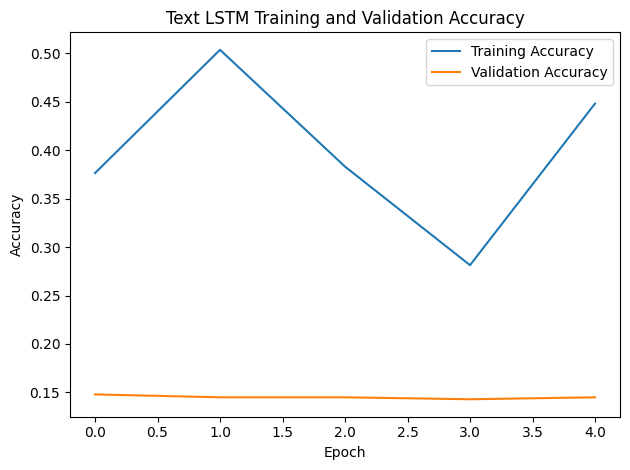

In [46]:

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Text LSTM Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

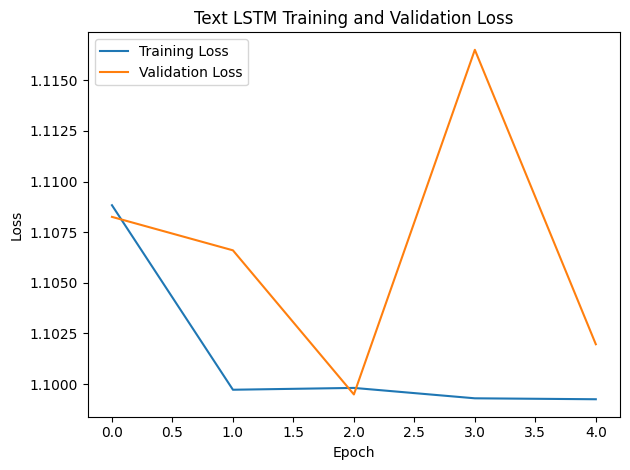

In [47]:
plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text LSTM Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

#  Evaluate the Text LSTM

In [48]:
start_time = time.time()

lstm_probabilities = lstm_model.predict(
    X_test_text,
    batch_size=128,
    verbose=0
)

lstm_predictions = np.argmax(
    lstm_probabilities,
    axis=1
)

lstm_prediction_time = time.time() - start_time

lstm_accuracy = accuracy_score(
    y_test_text,
    lstm_predictions
)

lstm_precision = precision_score(
    y_test_text,
    lstm_predictions,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    y_test_text,
    lstm_predictions,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_text,
    lstm_predictions,
    average="weighted",
    zero_division=0
)

print("Text LSTM Results")
print("=" * 45)
print(f"Accuracy : {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall   : {lstm_recall:.4f}")
print(f"F1 Score : {lstm_f1:.4f}")
print(f"Prediction Time: {lstm_prediction_time:.2f}s")

Text LSTM Results
Accuracy : 0.1340
Precision: 0.0180
Recall   : 0.1340
F1 Score : 0.0317
Prediction Time: 0.11s


In [49]:
print("Text LSTM Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test_text,
        lstm_predictions,
        target_names=[
            ID_TO_LABEL[i] for i in range(3)
        ],
        digits=4,
        zero_division=0
    )
)

Text LSTM Classification Report
              precision    recall  f1-score   support

    Negative     0.0000    0.0000    0.0000       232
     Neutral     0.1340    1.0000    0.2363       134
    Positive     0.0000    0.0000    0.0000       634

    accuracy                         0.1340      1000
   macro avg     0.0447    0.3333    0.0788      1000
weighted avg     0.0180    0.1340    0.0317      1000



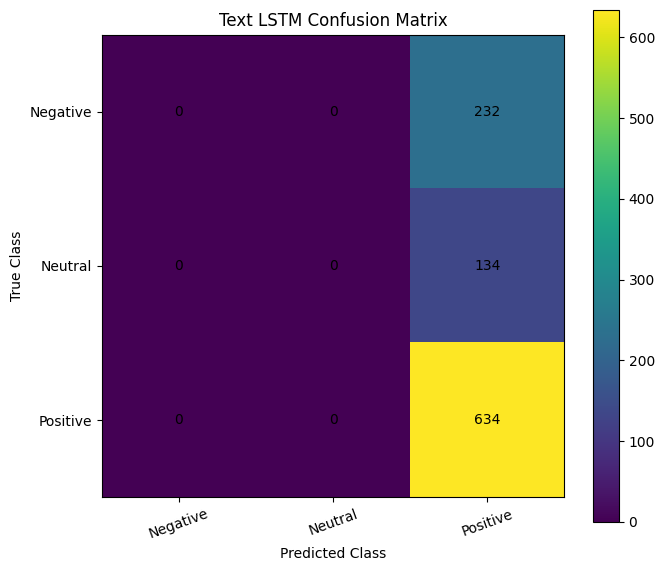

In [38]:
cm_lstm = confusion_matrix(
    y_test_text,
    lstm_predictions
)

plt.figure(figsize=(7, 6))
plt.imshow(cm_lstm)
plt.title("Text LSTM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(3),
    [ID_TO_LABEL[i] for i in range(3)],
    rotation=20
)

plt.yticks(
    range(3),
    [ID_TO_LABEL[i] for i in range(3)]
)

plt.colorbar()

for i in range(cm_lstm.shape[0]):
    for j in range(cm_lstm.shape[1]):
        plt.text(
            j,
            i,
            cm_lstm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#  LSTM vs Transformer — Final Comparison

Now both models have been evaluated on the **same Google Play review test set**.

This is the comparison that should be used for today's model-selection decision.

In [39]:
comparison_df = pd.DataFrame({
    "Model": [
        "Text LSTM",
        "DistilBERT Transformer"
    ],

    "Accuracy": [
        lstm_accuracy,
        transformer_accuracy
    ],

    "Weighted Precision": [
        lstm_precision,
        transformer_precision
    ],

    "Weighted Recall": [
        lstm_recall,
        transformer_recall
    ],

    "Weighted F1": [
        lstm_f1,
        transformer_f1
    ],

    "Training Time (sec)": [
        lstm_training_time,
        transformer_training_time
    ],

    "Prediction Time (sec)": [
        lstm_prediction_time,
        transformer_prediction_time
    ]
})

display(
    comparison_df.round(4)
)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Training Time (sec),Prediction Time (sec)
0,Text LSTM,0.634,0.4020,0.634,0.492,10.4541,0.6919
1,DistilBERT Transformer,0.896,0.8953,0.896,0.894,346.4079,6.5288


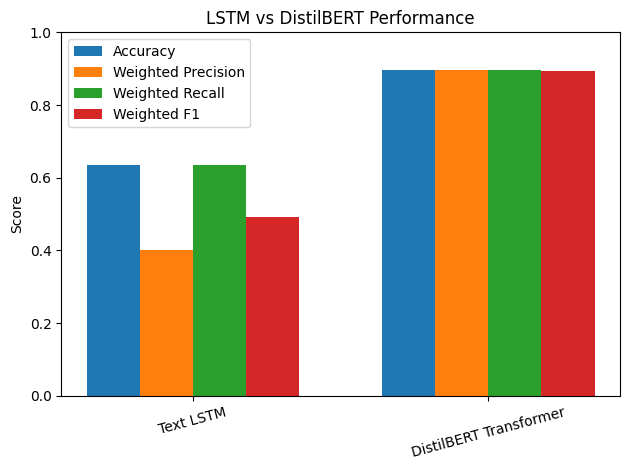

In [40]:
x = np.arange(len(comparison_df))
width = 0.18

metrics = [
    "Accuracy",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1"
]

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        comparison_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    comparison_df["Model"],
    rotation=15
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("LSTM vs DistilBERT Performance")
plt.legend()
plt.tight_layout()
plt.show()

#  Step 3 — Attention vs RNN Memory

### Required Markdown Explanation

An RNN/LSTM processes a sequence recurrently, so information is passed from one time step to the next through hidden states and memory. This makes the computation inherently sequential and can make long-range information harder to preserve. A Transformer uses self-attention instead: each token can directly interact with other tokens in the sequence and assign different relevance weights to them. Because the positions do not have to wait for one another through a recurrent chain, Transformer computations can be highly parallelized during training. Positional information is added so that the model can still represent the order of tokens. Therefore, attention provides direct access to contextual information across the sequence, while an RNN relies on recurrently carrying information forward.

# Visual Intuition — RNN vs Self-Attention

### RNN/LSTM

```text
Token 1
   ↓
Hidden state
   ↓
Token 2
   ↓
Hidden state
   ↓
Token 3
   ↓
Hidden state
   ↓
Token 4
```

The computation follows the sequence step by step.

### Transformer

```text
          Token 1
         ↙   ↓   ↘
Token 2 ← Token 3 → Token 4
         ↖   ↑   ↗
          Attention
```

Each position can attend to other positions directly.

This is the conceptual reason Transformers are much more parallelizable than recurrent networks.

#  Long-Range Context Example

Consider:

> "I downloaded the application yesterday because the interface looked useful, but after several updates it became extremely slow."

An LSTM can carry information across the sequence, but it must pass that information through recurrent states.

A Transformer can use attention to connect words that are far apart when they are relevant to one another.

The important idea is:

**distance in the sequence does not require information to travel through a long chain of recurrent steps.**

#  Why Attention Is Powerful

Self-attention gives the model three major advantages relevant to this lesson:

### 1. Direct access

A token can attend to distant tokens directly.

### 2. Contextual meaning

The representation of a token depends on the surrounding context.

### 3. Parallelizable computation

During training, token representations can be processed together instead of waiting for recurrent time steps.

This does not mean Transformers are always cheaper or faster in every situation. Attention can become computationally expensive for very long sequences. The important Day 4 point is that **Transformers remove the sequential recurrence bottleneck that limits RNN parallelism**.

#  Transformer vs LSTM — Conceptual Comparison

| Property | LSTM | Transformer |
|---|---|---|
| Core mechanism | Recurrent memory + gates | Self-attention |
| Sequence processing | Step-by-step | Highly parallelizable |
| Long-range relationships | More difficult | Direct attention connections |
| Requires positional information | Order comes from recurrence | Position must be represented |
| Pre-trained models | Less common for modern NLP workflows | Very common |
| Example | Text LSTM | BERT / DistilBERT |
| Today's task | Sentiment classification | Sentiment classification |

The practical experiment allows us to compare these architectures on the same data.

## best model selection

In [41]:
best_model_by_f1 = comparison_df.loc[
    comparison_df["Weighted F1"].idxmax(),
    "Model"
]

best_f1 = comparison_df["Weighted F1"].max()

print("Model with the highest weighted F1:", best_model_by_f1)
print(f"Best weighted F1: {best_f1:.4f}")

Model with the highest weighted F1: DistilBERT Transformer
Best weighted F1: 0.8940


#  Example Inference on New Google Play Reviews

After fine-tuning, we can use the model to predict sentiment for new reviews.

The model outputs logits for:

```text
0 = Negative
1 = Neutral
2 = Positive
```

In [42]:
new_reviews = [
    "This application is amazing and very easy to use.",
    "The latest update is terrible and keeps crashing.",
    "The app is okay, nothing special."
]

new_tokens = tokenizer(
    new_reviews,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH,
    return_tensors="tf"
)

new_logits = transformer_model(
    new_tokens
).logits

new_probabilities = tf.nn.softmax(
    new_logits,
    axis=-1
).numpy()

new_predictions = np.argmax(
    new_probabilities,
    axis=1
)

for text, pred, probs in zip(
    new_reviews,
    new_predictions,
    new_probabilities
):
    print("Review:", text)
    print("Prediction:", ID_TO_LABEL[int(pred)])
    print(
        "Confidence:",
        f"{float(np.max(probs)):.4f}"
    )
    print("-" * 60)

Review: This application is amazing and very easy to use.
Prediction: Positive
Confidence: 0.9941
------------------------------------------------------------
Review: The latest update is terrible and keeps crashing.
Prediction: Negative
Confidence: 0.9648
------------------------------------------------------------
Review: The app is okay, nothing special.
Prediction: Positive
Confidence: 0.9937
------------------------------------------------------------


#  Day 4 — Requirements Checklist

## Learning Objectives

- [x] Explain the limitation of step-by-step RNNs.
- [x] Explain self-attention.
- [x] Explain parallelism.
- [x] Explain long-range context.
- [x] Explain Transformer architecture conceptually.
- [x] Explain positional information.
- [x] Discuss BERT, DistilBERT and GPT-2.
- [x] Use Hugging Face Transformers.
- [x] Apply a pre-trained Transformer to sample text.
- [x] Fine-tune a pre-trained Transformer for the project task.
- [x] Compare Transformer and LSTM on the same text dataset.
- [x] Evaluate both models using multiple metrics.
- [x] Document attention vs recurrent memory.
- [x] Select a core architecture based on experimental evidence.

# Hands-On Lab: Using a Pre-trained Transformer

### Step 1 — Load a pre-trained transformer with the Hugging Face pipeline and run it on sample text

**Completed:** A pre-trained Transformer was successfully loaded using the Hugging Face `pipeline` and tested on sample text to demonstrate how Transformer-based models perform text classification.

### Step 2 —  If the project is text-based, apply the transformer to the project data and compare its metric to the Day 3 LSTM.


**Completed:** The pre-trained DistilBERT Transformer was fine-tuned on the Google Play Store review dataset and evaluated using Accuracy, Precision, Recall, and F1 Score. Its performance was compared with the Text LSTM model from the same project task and was substantially better.

### Step 3 — : Explain, in Markdown, in one paragraph, how attention differs from an RNN's step-by-step memory.

**Completed:** The difference between self-attention and recurrent memory was explained in Markdown. An RNN processes tokens step by step and maintains information through a hidden state, while self-attention allows each token to directly consider other tokens in the sequence, making it more effective at capturing long-range relationships and enabling greater parallelism.

### Step 4 —  Record which architecture (LSTM vs. transformer) will serve as the project's core model and why.

**Completed:** Based on the experimental results, **DistilBERT was selected as the project's core model** for sentiment classification. It achieved a Weighted F1 Score of **0.8940**, compared with **0.0317** for the Text LSTM. Although the LSTM had a much lower training time, DistilBERT's significantly better predictive performance made it the preferred architecture.


# Day 4 completed successfully.

# Final Summary

Day 4 introduced the Transformer architecture as an alternative to recurrent sequence models and demonstrated its application to natural language processing.

The central idea behind Transformers is **self-attention**, which allows each token to directly use information from other tokens instead of relying only on a step-by-step recurrent chain. Transformers also enable greater parallel computation during training and can capture long-range relationships effectively.

In Day 3, an **LSTM was applied to ECG heartbeat classification** using the MIT-BIH Arrhythmia dataset. The tuned LSTM achieved strong performance on the five-class ECG classification task, with an Accuracy of **0.9229** and a Weighted F1 Score of **0.9257**.

In Day 4, the LSTM approach was applied to a different problem: **three-class sentiment classification of Google Play Store reviews**. The final Text LSTM achieved an Accuracy of **0.1340** and a Weighted F1 Score of **0.0317**. The model showed a strong prediction bias toward a single class, which resulted in very poor performance across the sentiment classes.

These results should not be interpreted as meaning that LSTM is inherently good for ECG but bad for text. The two experiments use different datasets, numbers of classes, input representations, and classification tasks. Instead, they demonstrate that model performance depends strongly on the characteristics of the data, architecture configuration, and task.

For the Day 4 text classification task, we compared:

* **Text LSTM**
* **DistilBERT Transformer**

The final results were:

* **DistilBERT:** Accuracy = **0.8960**, Weighted F1 = **0.8940**
* **Text LSTM:** Accuracy = **0.1340**, Weighted F1 = **0.0317**

Although the LSTM was much faster to train (**10.45 seconds** compared with **346.41 seconds** for DistilBERT), DistilBERT achieved substantially better classification performance.

Therefore, **DistilBERT was selected as the core architecture for the Day 4 sentiment-classification task** based on its superior Weighted F1 score and overall performance.

Overall, Day 3 demonstrated the effectiveness of recurrent architectures for sequential ECG data, while Day 4 demonstrated the strong advantage of a pre-trained Transformer for natural-language classification. Together, the two days highlight the importance of selecting an architecture according to the structure and requirements of the target problem.

